Running Scenario 1: Baseline (No Intervention)...


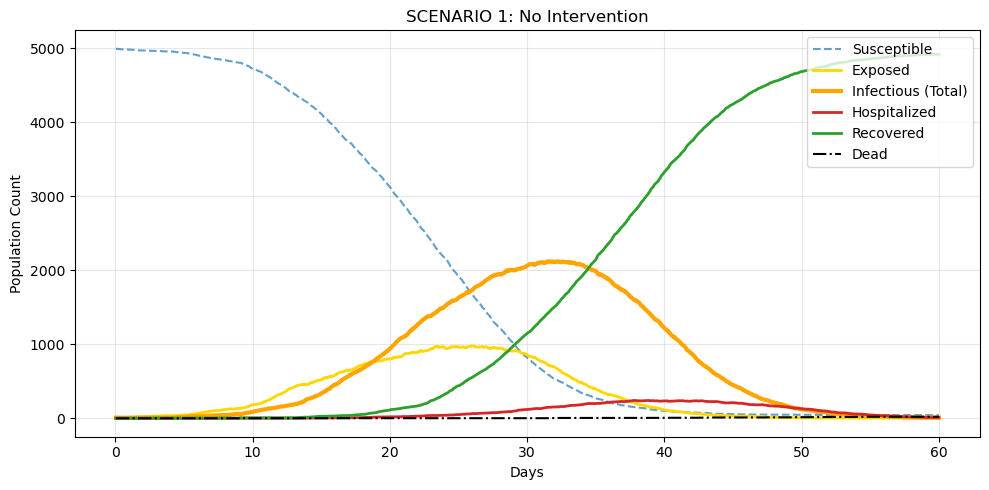

Running Scenario 2: Intervention starting Day 20...


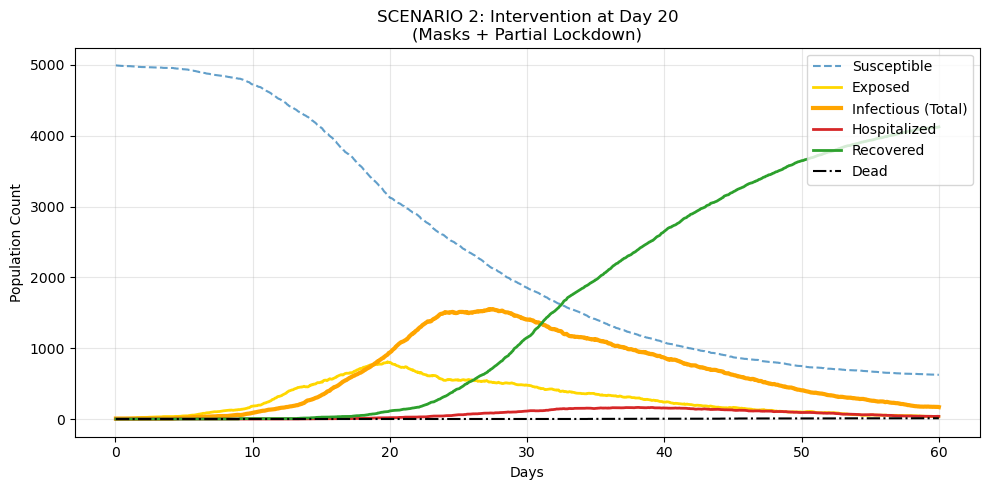

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import infection_model_npi as model  # Assuming you saved the previous code as this filename

# --- 1. Setup Parameters (Fixed for both runs) ---
params = model.Params(
    T=60 * 24,  # 60 days
    N=5000,
    alpha=3,
    initial_infected_normal=5,         # Increased slightly to ensure outbreak
    initial_infected_multispreader=2,
    ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=4,
    primary_care=20,
    hospitals=1,
    other_working_places=100,
    public_places=50
)

# --- 2. Define the Plotting Function (Adapted) ---
def plot_run(df, params, title_override=None):
    """
    Plots the simulation run using the specific style requested.
    """
    # Pre-processing: Calculate Days and Total Infectious if missing
    if "days" not in df.columns:
        df["days"] = df["time"] / 24.0
    
    if "I_total" not in df.columns:
        # Sum of Asymptomatic (I0), Mild (I1), Severe (I2)
        df["I_total"] = df["I0"] + df["I1"] + df["I2"]

    # Style definitions
    colors = {
        "S": "tab:blue", "E": "gold", "I_total": "orange",
        "H": "tab:red", "R": "tab:green", "D": "black"
    }
    
    plt.figure(figsize=(10, 5))
    
    # Plotting
    plt.plot(df["days"], df["S"], label="Susceptible", color=colors["S"], linestyle="--", alpha=0.7)
    plt.plot(df["days"], df["E"], label="Exposed", color=colors["E"], linewidth=2)
    plt.plot(df["days"], df["I_total"], label="Infectious (Total)", color=colors["I_total"], linewidth=3)
    plt.plot(df["days"], df["H"], label="Hospitalized", color=colors["H"], linewidth=2)
    plt.plot(df["days"], df["R"], label="Recovered", color=colors["R"], linewidth=2)
    plt.plot(df["days"], df["D"], label="Dead", color=colors["D"], linestyle="-.")

    # Labels and Grid
    plt.xlabel("Days")
    plt.ylabel("Population Count")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    
    # Title
    if title_override:
        plt.title(title_override)
    else:
        plt.title(f"Simulation Run\nInit N={params.initial_infected_normal} M={params.initial_infected_multispreader}")
    
    plt.tight_layout()
    plt.show()

# --- 3. Scenario 1: No Intervention (Baseline) ---
print("Running Scenario 1: Baseline (No Intervention)...")
sim_baseline = model.Simulation(params, seed=42) # Fixed seed for reproducibility
sim_baseline.init()
sim_baseline.run()

# Process Data
df_baseline = pd.DataFrame(sim_baseline.get_stats_df())

# Plot
plot_run(df_baseline, params, title_override="SCENARIO 1: No Intervention")

# --- 4. Scenario 2: Intervention at Day 20 ---
print("Running Scenario 2: Intervention starting Day 20...")
sim_intervention = model.Simulation(params, seed=42) # Same seed to compare apples-to-apples
sim_intervention.init()

# Define Policy: Masks + Partial Lockdown (Schools & Public Places closed)
policy = model.InterventionPolicy(
    masks_enabled=True,
    mask_efficiency=0.5,       # 50% reduction in transmission
    school_closure=True,
    public_places_closed=True,
    social_events_banned=True
)

# Schedule the intervention at Day 20 (20 * 24 hours)
sim_intervention.schedule_intervention(time=20*24, policy=policy, name="Day 20 Lockdown")

sim_intervention.run()

# Process Data
df_intervention = pd.DataFrame(sim_intervention.get_stats_df())

# Plot
plot_run(df_intervention, params, title_override="SCENARIO 2: Intervention at Day 20\n(Masks + Partial Lockdown)")

Planowanie roku 2020...
Start symulacji...
Koniec.


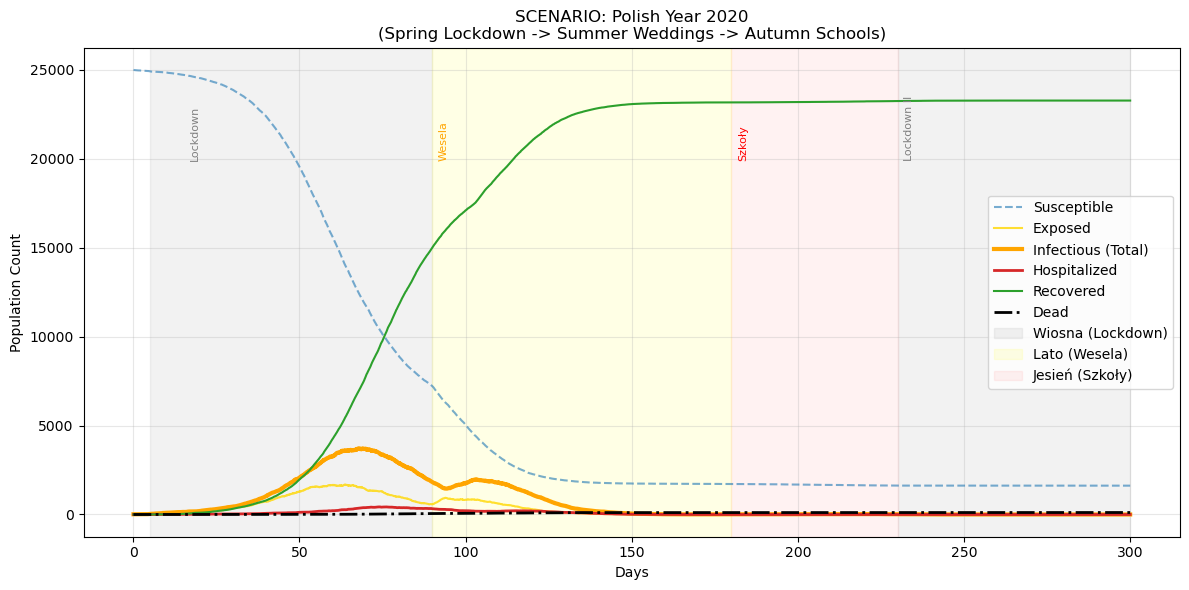

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import infection_model_npi as model

# --- 1. Konfiguracja Parametrów ---
params = model.Params(
    T=300 * 24,       # 300 dni (Marzec - Grudzień)
    N=25000,
    alpha=3,
    initial_infected_normal=10,        # Lekko więcej, żeby wirus przetrwał do lata
    initial_infected_multispreader=3,
    ratios=model.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=20,
    primary_care=100,
    hospitals=1,
    other_working_places=500,
    public_places=250
)

# Definicja wydarzenia "Wesele"
# Będzie aktywne tylko wtedy, gdy polityka na to pozwoli (social_events_banned=False)
wedding_event = model.PublicEvent(
    name="Wesele",
    frequency=7 * 24,   # Co tydzień
    size=0.03,          # 3% populacji (ok. 150 osób dla N=5000)
    duration=10.0,      # 10 godzin
    composition=0.0     # Losowi ludzie
)

# Inicjalizacja z wydarzeniami
sim = model.Simulation(params, public_events=[wedding_event], seed=2020)
sim.init()

# --- 2. Definicja Polityk (Scenariusze Lockdownu) ---

# A. WIOSNA (Hard Lockdown)
policy_spring = model.InterventionPolicy(
    school_closure=True,
    public_places_closed=True,
    social_events_banned=True,         # Wesela ZABRONIONE
    non_essential_workplaces_closed=True,
    masks_enabled=True,
    mask_efficiency=0.6
)

# B. LATO (Iluzja normalności)
# Wszystko otwarte, wesela dozwolone, brak maseczek (lub fikcyjne)
policy_summer = model.InterventionPolicy(
    school_closure=True,               # Szkoły zamknięte (wakacje)
    public_places_closed=False,        # Parki/Gastronomia otwarte
    social_events_banned=False,        # Wesela DOZWOLONE
    non_essential_workplaces_closed=False,
    masks_enabled=False,               # "Wirus w odwrocie"
    mask_efficiency=0.2, # nadal dystans i maski ale nie wszyscy
    wfh_enabled=True,
    wfh_non_essential_fraction=0.3
)

# C. JESIEŃ (Szkoły wracają)
# Wrzesień: Dzieci wracają do szkół, reszta działa w miarę normalnie
policy_autumn_school = model.InterventionPolicy(
    school_closure=False,              # SZKOŁY OTWARTE (Hub wirusa)
    public_places_closed=False,
    social_events_banned=False,
    non_essential_workplaces_closed=False,
    masks_enabled=True,
    mask_efficiency=0.2               # Niska dyscyplina
)

# D. JESIEŃ (Lockdown wtórny)
# Październik/Listopad: Reakcja na falę zakażeń
policy_autumn_lockdown = model.InterventionPolicy(
    school_closure=True,               # Zamykamy szkoły
    public_places_closed=True,         # Zamykamy gastronomię
    social_events_banned=True,         # Zakaz wesel
    non_essential_workplaces_closed=False, # Praca działa (niepełny lockdown)
    wfh_enabled=True,
    wfh_non_essential_fraction=0.5,
    masks_enabled=True,
    mask_efficiency=0.50               # Wyższa dyscyplina (strach)
)

# --- 3. Harmonogram (Schedule) ---

print("Planowanie roku 2020...")

# Dzień 15: Wiosenny Lockdown
sim.schedule_intervention(5 * 24, policy_spring, "Wiosna: Lockdown")

# Dzień 90 (Czerwiec): Lato / Odwilż
sim.schedule_intervention(90 * 24, policy_summer, "Lato: Otwarcie + Wesela")

# Dzień 180 (Wrzesień): Powrót do szkół
sim.schedule_intervention(180 * 24, policy_autumn_school, "Jesień: Szkoły Start")

# Dzień 230 (Połowa Października): Jesienny Lockdown
sim.schedule_intervention(230 * 24, policy_autumn_lockdown, "Jesień: Lockdown")

# --- 4. Uruchomienie ---
print("Start symulacji...")
sim.run()
print("Koniec.")

# --- 5. Wizualizacja ---

def plot_poland_scenario(df, params):
    # Przygotowanie danych
    if "days" not in df.columns:
        df["days"] = df["time"] / 24.0
    if "I_total" not in df.columns:
        df["I_total"] = df["I0"] + df["I1"] + df["I2"]

    colors = {
        "S": "tab:blue", "E": "gold", "I_total": "orange",
        "H": "tab:red", "R": "tab:green", "D": "black"
    }

    plt.figure(figsize=(12, 6))

    # Linie wykresu
    plt.plot(df["days"], df["S"], label="Susceptible", color=colors["S"], linestyle="--", alpha=0.6)
    plt.plot(df["days"], df["E"], label="Exposed", color=colors["E"], alpha=0.8)
    plt.plot(df["days"], df["I_total"], label="Infectious (Total)", color=colors["I_total"], linewidth=3)
    plt.plot(df["days"], df["H"], label="Hospitalized", color=colors["H"], linewidth=2)
    plt.plot(df["days"], df["R"], label="Recovered", color=colors["R"])
    plt.plot(df["days"], df["D"], label="Dead", color=colors["D"], linestyle="-.", linewidth=2)

    # Tło dla etapów (Fazy roku)
    # Wiosna (Lockdown)
    plt.axvspan(5, 90, color='gray', alpha=0.1, label='Wiosna (Lockdown)')
    # Lato (Wesela)
    plt.axvspan(90, 180, color='yellow', alpha=0.1, label='Lato (Wesela)')
    # Jesień (Szkoła)
    plt.axvspan(180, 230, color='red', alpha=0.05, label='Jesień (Szkoły)')
    # Jesień (Lockdown)
    plt.axvspan(230, 300, color='gray', alpha=0.1)

    # Opisy na osi czasu
    y_txt = params.N * 0.8
    plt.text(15+2, y_txt, "Lockdown", rotation=90, color='gray', fontsize=8)
    plt.text(90+2, y_txt, "Wesela", rotation=90, color='orange', fontsize=8)
    plt.text(180+2, y_txt, "Szkoły", rotation=90, color='red', fontsize=8)
    plt.text(230+2, y_txt, "Lockdown II", rotation=90, color='gray', fontsize=8)

    plt.xlabel("Days")
    plt.ylabel("Population Count")
    plt.title(f"SCENARIO: Polish Year 2020\n(Spring Lockdown -> Summer Weddings -> Autumn Schools)")
    plt.legend(loc="center right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Wywołanie plotowania
df_result = pd.DataFrame(sim.get_stats_df())
plot_poland_scenario(df_result, params)